In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': 'white',
    'axes.facecolor': '#fafafa',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 14,
    'axes.labelsize': 11,
})

BRAND   = ['#6F4E37','#C8860A','#A0522D','#D2691E','#8B5E3C',
           '#F4A460','#DEB887','#CD853F','#B8860B','#DAA520']
FMT_USD = mticker.FuncFormatter(lambda x, _: f'${x:,.0f}')
FMT_NUM = mticker.FuncFormatter(lambda x, _: f'{x:,.0f}')

print('Libraries loaded successfully')

Libraries loaded successfully


In [ ]:
df = pd.read_csv('Afficionado Coffee Roasters.xlsx - Transactions.csv')
print(f'Shape : {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()

Shape : 149,116 rows x 11 columns


,transaction_id,year,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2025,7:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2025,7:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2025,7:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2025,7:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2025,7:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [23]:
print('=' * 55)
print('  DATA VALIDATION REPORT')
print('=' * 55)

missing = df.isnull().sum()
print('Missing values:')
print(missing[missing > 0] if missing.sum() > 0 else '  None - dataset complete')

print(f'\nInvalid transaction_qty (<=0) : {(df["transaction_qty"] <= 0).sum()}')
print(f'Invalid unit_price     (<=0) : {(df["unit_price"] <= 0).sum()}')
print(f'\nUnique products        : {df["product_detail"].nunique()}')
print(f'Unique product types   : {df["product_type"].nunique()}')
print(f'Unique categories      : {df["product_category"].nunique()}')
print(f'Store locations        : {df["store_location"].unique().tolist()}')
print('=' * 55)df_clean = df[(df['transaction_qty'] > 0) & (df['unit_price'] > 0)].copy()
df_clean['revenue'] = df_clean['transaction_qty'] * df_clean['unit_price']

TOTAL_REVENUE = df_clean['revenue'].sum()

print(f'Clean rows    : {len(df_clean):,}')
print(f'Total Revenue : ${TOTAL_REVENUE:,.2f}')
df_clean[['transaction_qty', 'unit_price', 'revenue']].describe().round(2)

  DATA VALIDATION REPORT
Missing values:
  None - dataset complete

Invalid transaction_qty (<=0) : 0
Invalid unit_price     (<=0) : 0

Unique products        : 80
Unique product types   : 29
Unique categories      : 9
Store locations        : ['Lower Manhattan', "Hell's Kitchen", 'Astoria']


In [24]:
df_clean = df[(df['transaction_qty'] > 0) & (df['unit_price'] > 0)].copy()
df_clean['revenue'] = df_clean['transaction_qty'] * df_clean['unit_price']

TOTAL_REVENUE = df_clean['revenue'].sum()

print(f'Clean rows    : {len(df_clean):,}')
print(f'Total Revenue : ${TOTAL_REVENUE:,.2f}')
df_clean[['transaction_qty', 'unit_price', 'revenue']].describe().round(2)

Clean rows    : 149,116
Total Revenue : $698,812.33


,transaction_qty,unit_price,revenue
count,149116.00,149116.00,149116.00
mean,1.44,3.38,4.69
std,0.54,2.66,4.23
min,1.00,0.80,0.80
25%,1.00,2.50,3.00
50%,1.00,3.00,3.75
75%,2.00,3.75,6.00
max,8.00,45.00,360.00


In [25]:
popularity = (
    df_clean.groupby('product_detail')['transaction_qty']
    .sum().reset_index()
    .rename(columns={'transaction_qty': 'units_sold'})
    .sort_values('units_sold', ascending=False)
    .reset_index(drop=True)
)
popularity['popularity_rank'] = popularity.index + 1

print(f'Total products: {len(popularity)}')
popularity.head(10)

Total products: 80


,product_detail,units_sold,popularity_rank
0,Earl Grey Rg,4708,1
1,Dark chocolate Lg,4668,2
2,Morning Sunrise Chai Rg,4643,3
3,Latte,4602,4
4,Peppermint Rg,4564,5
5,Columbian Medium Roast Rg,4547,6
6,Traditional Blend Chai Rg,4512,7
7,Latte Rg,4497,8
8,Our Old Time Diner Blend Sm,4484,9
9,Serenity Green Tea Rg,4477,10


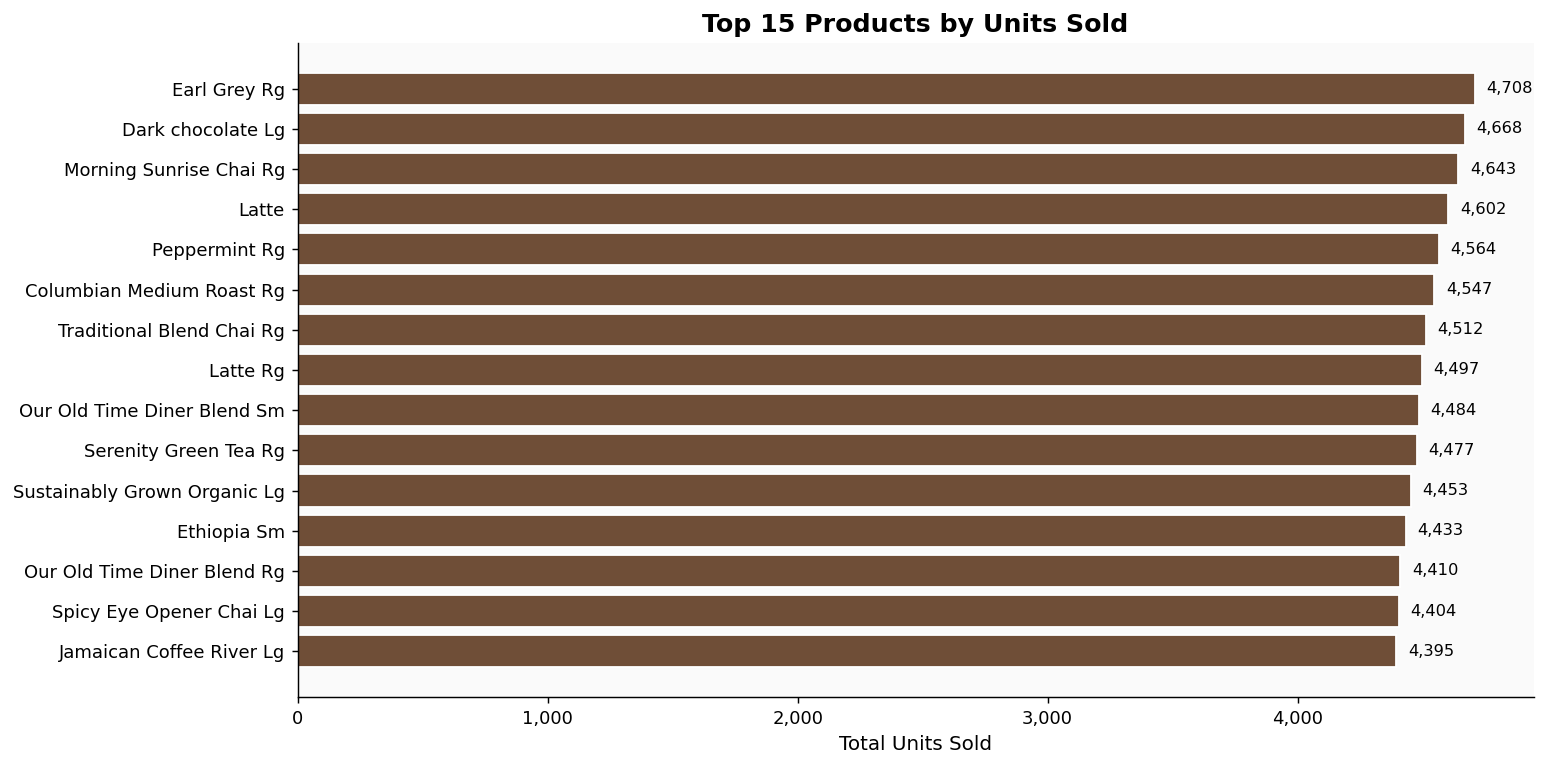

In [26]:
TOP_N = 15
top_pop = popularity.head(TOP_N)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_pop['product_detail'][::-1], top_pop['units_sold'][::-1],
               color=BRAND[0], edgecolor='white')
for bar in bars:
    ax.text(bar.get_width() + top_pop['units_sold'].max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width():,.0f}', va='center', fontsize=9)
ax.set_title(f'Top {TOP_N} Products by Units Sold', fontweight='bold')
ax.set_xlabel('Total Units Sold')
ax.xaxis.set_major_formatter(FMT_NUM)
plt.tight_layout()
plt.show()

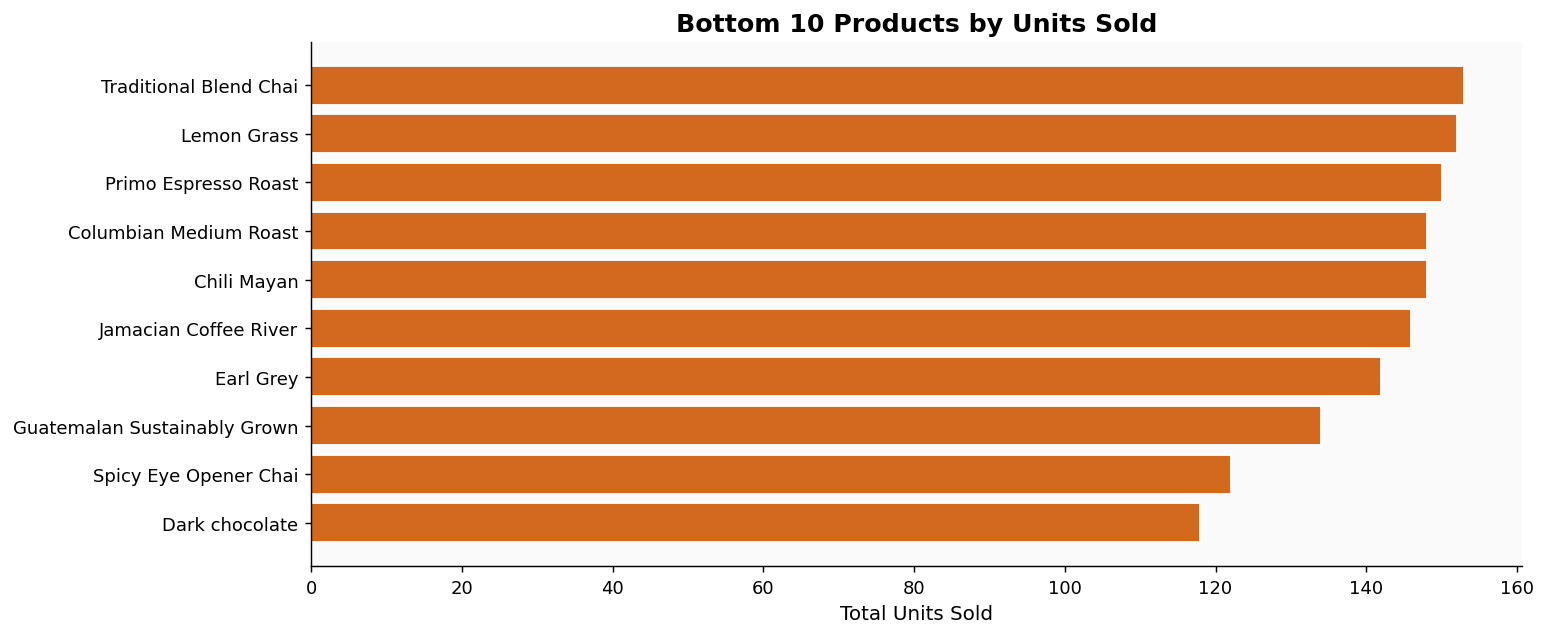

,product_detail,units_sold,popularity_rank
70,Traditional Blend Chai,153,71
71,Lemon Grass,152,72
72,Primo Espresso Roast,150,73
73,Columbian Medium Roast,148,74
74,Chili Mayan,148,75
75,Jamacian Coffee River,146,76
76,Earl Grey,142,77
77,Guatemalan Sustainably Grown,134,78
78,Spicy Eye Opener Chai,122,79
79,Dark chocolate,118,80


In [27]:
BOTTOM_N = 10
bottom_pop = popularity.tail(BOTTOM_N)

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(bottom_pop['product_detail'][::-1], bottom_pop['units_sold'][::-1],
        color='#D2691E', edgecolor='white')
ax.set_title(f'Bottom {BOTTOM_N} Products by Units Sold', fontweight='bold')
ax.set_xlabel('Total Units Sold')
plt.tight_layout()
plt.show()

bottom_pop[['product_detail', 'units_sold', 'popularity_rank']]

In [28]:
rev_product = (
    df_clean.groupby('product_detail')
    .agg(units_sold=('transaction_qty','sum'), total_revenue=('revenue','sum'))
    .reset_index()
    .sort_values('total_revenue', ascending=False)
    .reset_index(drop=True)
)
rev_product['revenue_rank']       = rev_product.index + 1
rev_product['revenue_share_pct']  = (rev_product['total_revenue'] / TOTAL_REVENUE * 100).round(2)
rev_product['cumulative_rev_pct'] = rev_product['revenue_share_pct'].cumsum().round(2)
rev_product = rev_product.merge(popularity[['product_detail','popularity_rank']], on='product_detail')

print(f'Total Revenue: ${TOTAL_REVENUE:,.2f}')
rev_product[['product_detail','units_sold','total_revenue','revenue_share_pct','cumulative_rev_pct']].head(10)

Total Revenue: $698,812.33


,product_detail,units_sold,total_revenue,revenue_share_pct,cumulative_rev_pct
0,Sustainably Grown Organic Lg,4453,21151.75,3.03,3.03
1,Dark chocolate Lg,4668,21006.00,3.01,6.04
2,Latte Rg,4497,19112.25,2.73,8.77
3,Cappuccino Lg,4151,17641.75,2.52,11.29
4,Morning Sunrise Chai Lg,4346,17384.00,2.49,13.78
5,Latte,4602,17257.50,2.47,16.25
6,Jamaican Coffee River Lg,4395,16481.25,2.36,18.61
7,Sustainably Grown Organic Rg,4329,16233.75,2.32,20.93
8,Cappuccino,4266,15997.50,2.29,23.22
9,Brazilian Lg,4317,15109.50,2.16,25.38


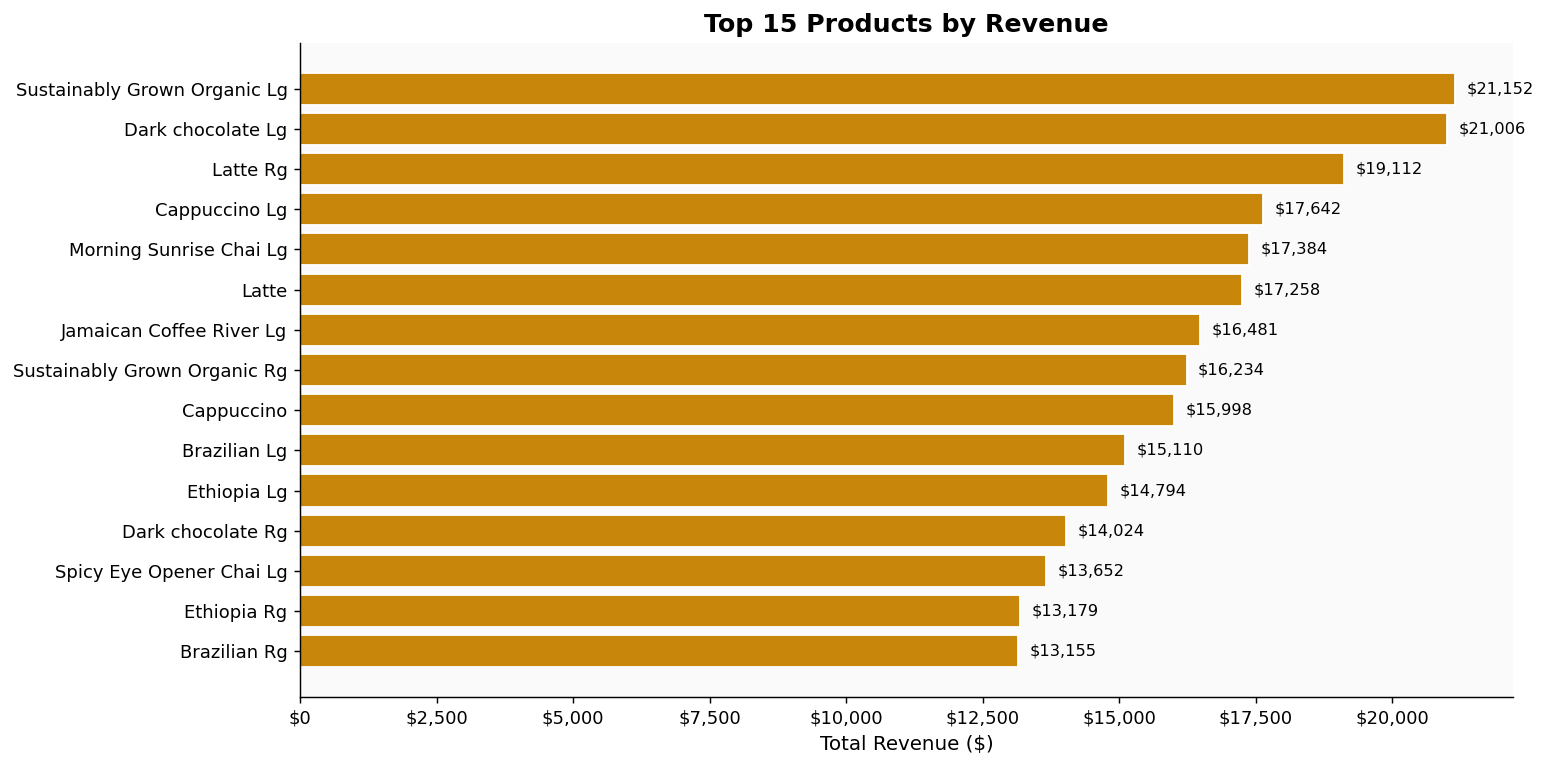

In [29]:
top_rev = rev_product.head(15)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_rev['product_detail'][::-1], top_rev['total_revenue'][::-1],
               color=BRAND[1], edgecolor='white')
for bar in bars:
    ax.text(bar.get_width() + top_rev['total_revenue'].max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'${bar.get_width():,.0f}', va='center', fontsize=9)
ax.set_title('Top 15 Products by Revenue', fontweight='bold')
ax.set_xlabel('Total Revenue ($)')
ax.xaxis.set_major_formatter(FMT_USD)
plt.tight_layout()
plt.show()

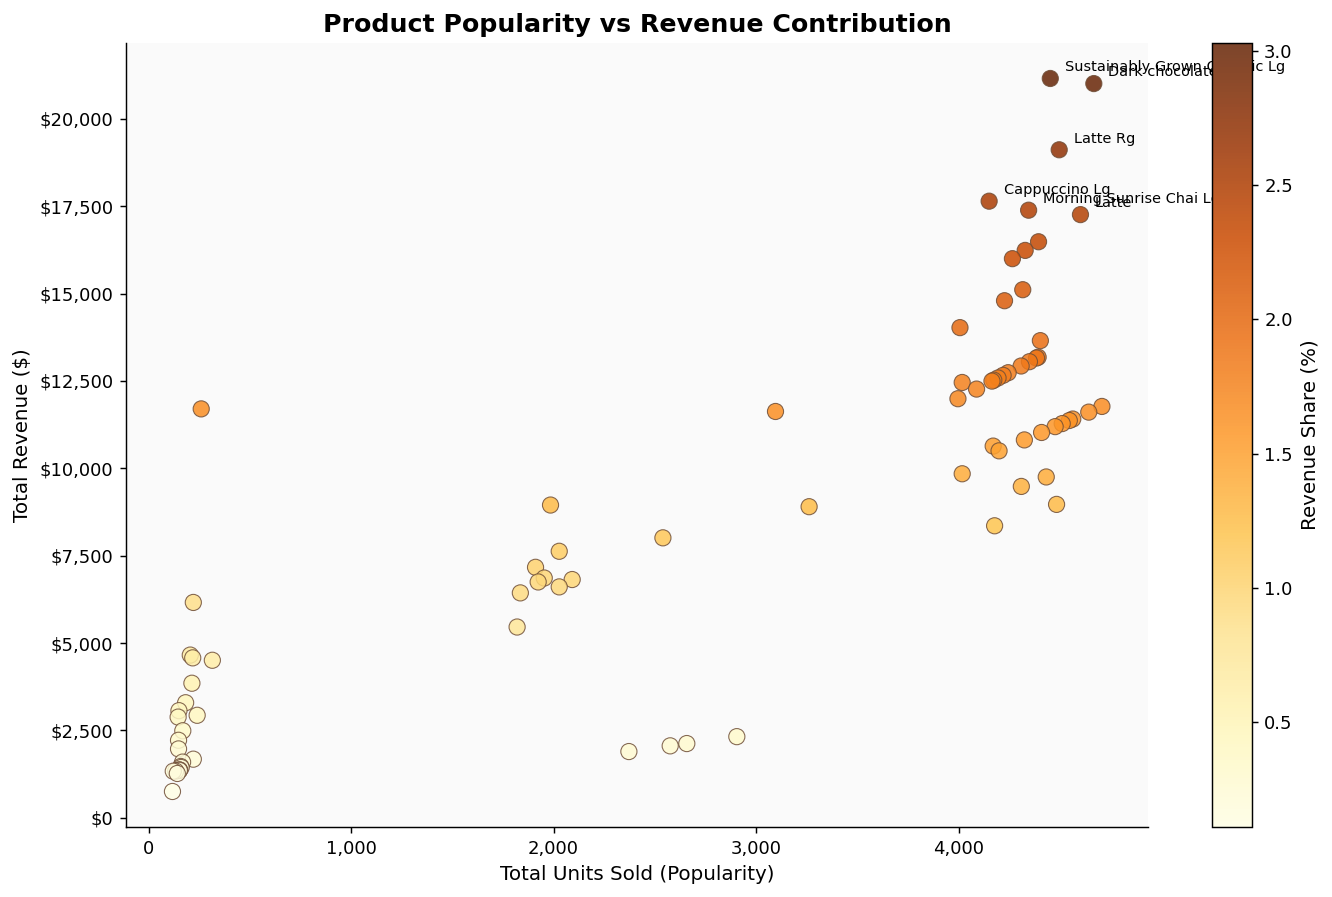

In [30]:
fig, ax = plt.subplots(figsize=(11, 7))
sc = ax.scatter(
    rev_product['units_sold'], rev_product['total_revenue'],
    c=rev_product['revenue_share_pct'], cmap='YlOrBr',
    s=80, edgecolors='#6F4E37', linewidths=0.6, alpha=0.85
)
plt.colorbar(sc, ax=ax, label='Revenue Share (%)')

for _, row in rev_product.head(6).iterrows():
    ax.annotate(row['product_detail'],
                xy=(row['units_sold'], row['total_revenue']),
                xytext=(8, 4), textcoords='offset points', fontsize=8)

ax.set_xlabel('Total Units Sold (Popularity)')
ax.set_ylabel('Total Revenue ($)')
ax.set_title('Product Popularity vs Revenue Contribution', fontweight='bold')
ax.xaxis.set_major_formatter(FMT_NUM)
ax.yaxis.set_major_formatter(FMT_USD)
plt.tight_layout()
plt.show()

In [31]:
cat_rev = (
    df_clean.groupby('product_category')
    .agg(units_sold=('transaction_qty','sum'), total_revenue=('revenue','sum'))
    .reset_index()
    .sort_values('total_revenue', ascending=False)
)
cat_rev['revenue_share_pct'] = (cat_rev['total_revenue'] / TOTAL_REVENUE * 100).round(2)
cat_rev

,product_category,units_sold,total_revenue,revenue_share_pct
2,Coffee,89250,269952.45,38.63
8,Tea,69737,196405.95,28.11
0,Bakery,23214,82315.64,11.78
4,Drinking Chocolate,17457,72416.00,10.36
3,Coffee beans,1828,40085.25,5.74
1,Branded,776,13607.00,1.95
6,Loose Tea,1210,11213.60,1.60
5,Flavours,10511,8408.80,1.20
7,Packaged Chocolate,487,4407.64,0.63


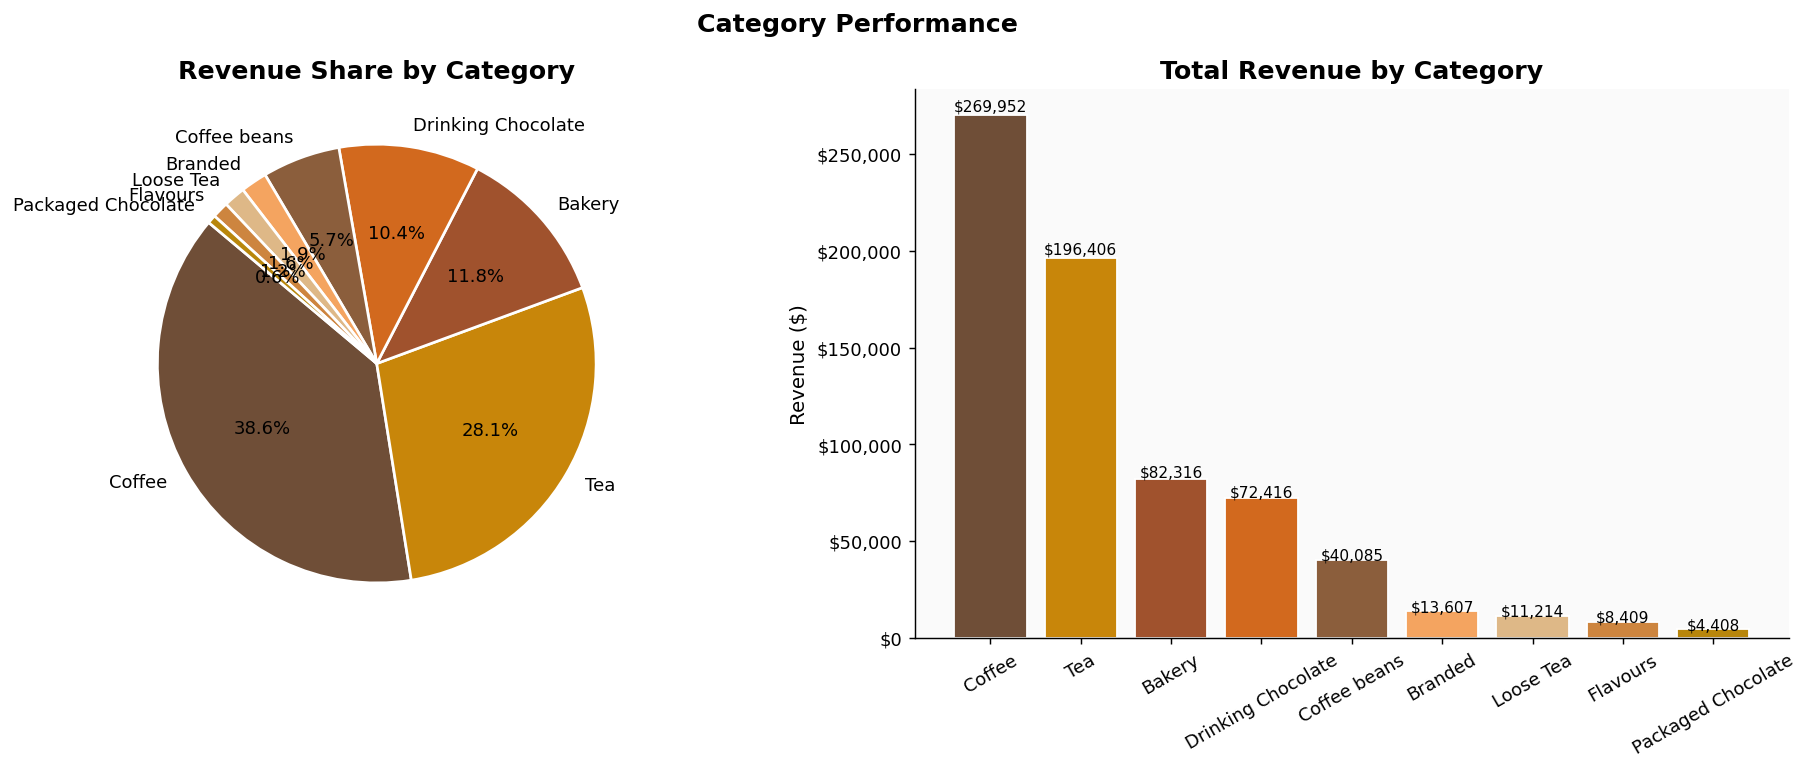

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].pie(cat_rev['total_revenue'],
            labels=cat_rev['product_category'],
            colors=BRAND[:len(cat_rev)],
            autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[0].set_title('Revenue Share by Category', fontweight='bold')

bars = axes[1].bar(cat_rev['product_category'], cat_rev['total_revenue'],
                   color=BRAND[:len(cat_rev)], edgecolor='white')
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                 f'${bar.get_height():,.0f}', ha='center', fontsize=8.5)
axes[1].set_title('Total Revenue by Category', fontweight='bold')
axes[1].set_ylabel('Revenue ($)')
axes[1].yaxis.set_major_formatter(FMT_USD)
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Category Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

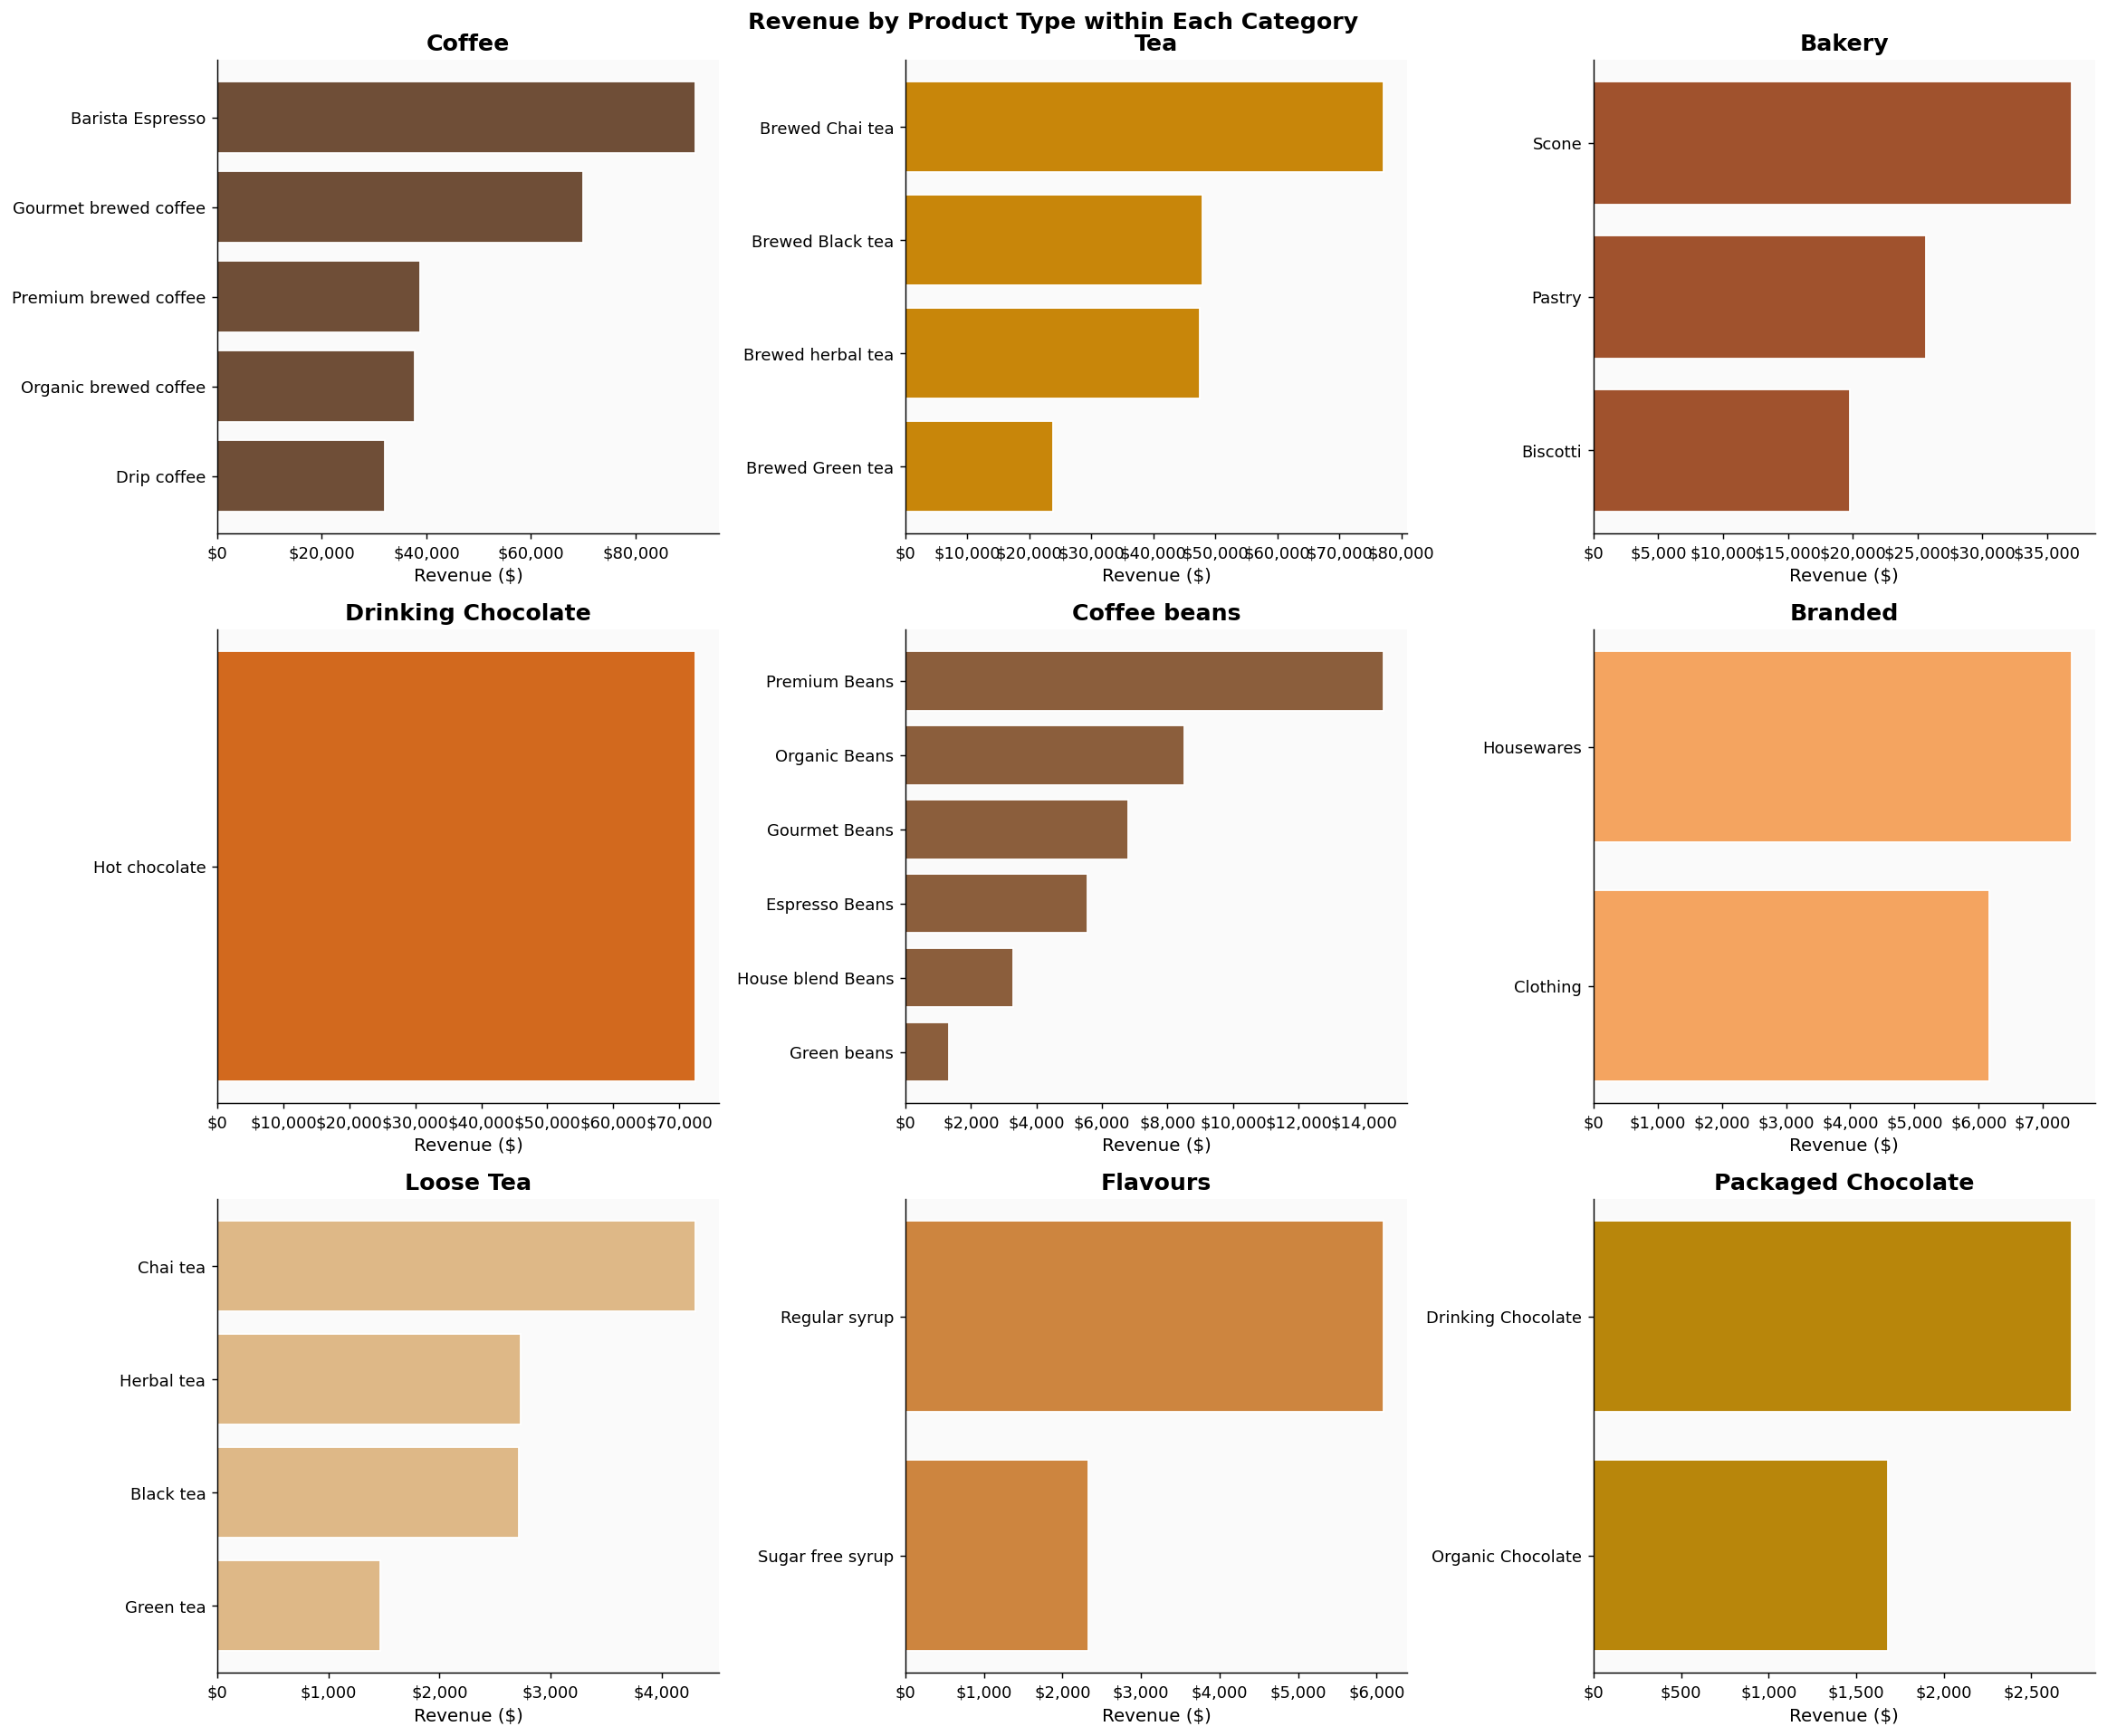

In [33]:
type_rev = (
    df_clean.groupby(['product_category','product_type'])
    .agg(units_sold=('transaction_qty','sum'), total_revenue=('revenue','sum'))
    .reset_index()
    .sort_values(['product_category','total_revenue'], ascending=[True,False])
)

categories = cat_rev['product_category'].tolist()
cols = 3
rows = (len(categories) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 5*rows))
axes_flat = axes.flatten()

for i, cat in enumerate(categories):
    subset = type_rev[type_rev['product_category'] == cat].head(8)
    axes_flat[i].barh(subset['product_type'][::-1], subset['total_revenue'][::-1],
                      color=BRAND[i % len(BRAND)], edgecolor='white')
    axes_flat[i].set_title(cat, fontweight='bold')
    axes_flat[i].set_xlabel('Revenue ($)')
    axes_flat[i].xaxis.set_major_formatter(FMT_USD)

for j in range(len(categories), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle('Revenue by Product Type within Each Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [34]:
pareto = rev_product[['product_detail','total_revenue',
                       'revenue_share_pct','cumulative_rev_pct']].copy()

products_80     = pareto[pareto['cumulative_rev_pct'] <= 80].shape[0] + 1
pct_products_80 = round(products_80 / len(pareto) * 100, 1)

print(f'Total products           : {len(pareto)}')
print(f'Products driving 80% rev : {products_80}  ({pct_products_80}% of menu)')
print(f'Long-tail products       : {len(pareto) - products_80}')
pareto.head(20)

Total products           : 80
Products driving 80% rev : 43  (53.8% of menu)
Long-tail products       : 37


,product_detail,total_revenue,revenue_share_pct,cumulative_rev_pct
0,Sustainably Grown Organic Lg,21151.75,3.03,3.03
1,Dark chocolate Lg,21006.00,3.01,6.04
2,Latte Rg,19112.25,2.73,8.77
3,Cappuccino Lg,17641.75,2.52,11.29
4,Morning Sunrise Chai Lg,17384.00,2.49,13.78
5,Latte,17257.50,2.47,16.25
6,Jamaican Coffee River Lg,16481.25,2.36,18.61
7,Sustainably Grown Organic Rg,16233.75,2.32,20.93
8,Cappuccino,15997.50,2.29,23.22
9,Brazilian Lg,15109.50,2.16,25.38


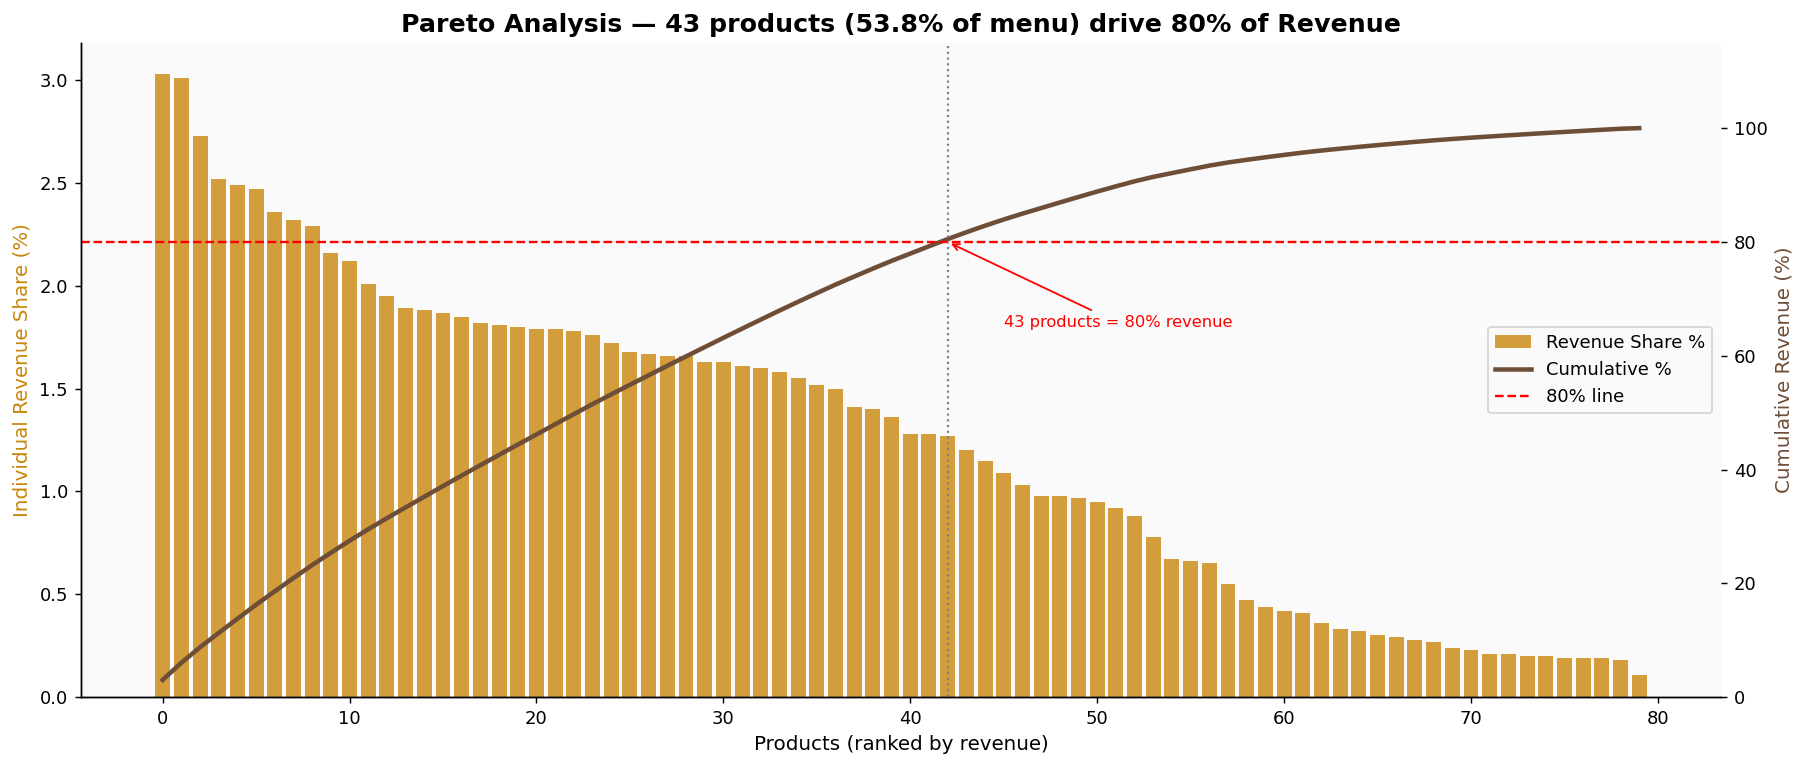

In [35]:
fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

x = range(len(pareto))
ax1.bar(x, pareto['revenue_share_pct'], color='#C8860A', alpha=0.8, label='Revenue Share %')
ax2.plot(x, pareto['cumulative_rev_pct'], color='#6F4E37', linewidth=2.5, label='Cumulative %')
ax2.axhline(80, color='red', linestyle='--', linewidth=1.3, label='80% line')
ax2.axvline(products_80 - 1, color='gray', linestyle=':', linewidth=1.2)

ax2.annotate(f'{products_80} products = 80% revenue',
             xy=(products_80-1, 80), xytext=(products_80+2, 65),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=9, color='red')

ax1.set_xlabel('Products (ranked by revenue)')
ax1.set_ylabel('Individual Revenue Share (%)', color='#C8860A')
ax2.set_ylabel('Cumulative Revenue (%)', color='#6F4E37')
ax2.set_ylim(0, 115)

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc='center right')
ax1.set_title(f'Pareto Analysis — {products_80} products ({pct_products_80}% of menu) drive 80% of Revenue',
              fontweight='bold')
plt.tight_layout()
plt.show()

In [36]:
med_units   = rev_product['units_sold'].median()
med_revenue = rev_product['total_revenue'].median()

def assign_quadrant(row):
    hi_vol = row['units_sold']    >= med_units
    hi_rev = row['total_revenue'] >= med_revenue
    if   hi_vol and hi_rev:      return 'Hero (High Vol, High Rev)'
    elif hi_vol and not hi_rev:  return 'Volume Driver (High Vol, Low Rev)'
    elif not hi_vol and hi_rev:  return 'Premium Niche (Low Vol, High Rev)'
    else:                        return 'Underperformer (Low Vol, Low Rev)'

rev_product['quadrant'] = rev_product.apply(assign_quadrant, axis=1)
print(rev_product['quadrant'].value_counts().to_string())

quadrant
Hero (High Vol, High Rev)            38
Underperformer (Low Vol, Low Rev)    38
Premium Niche (Low Vol, High Rev)     2
Volume Driver (High Vol, Low Rev)     2


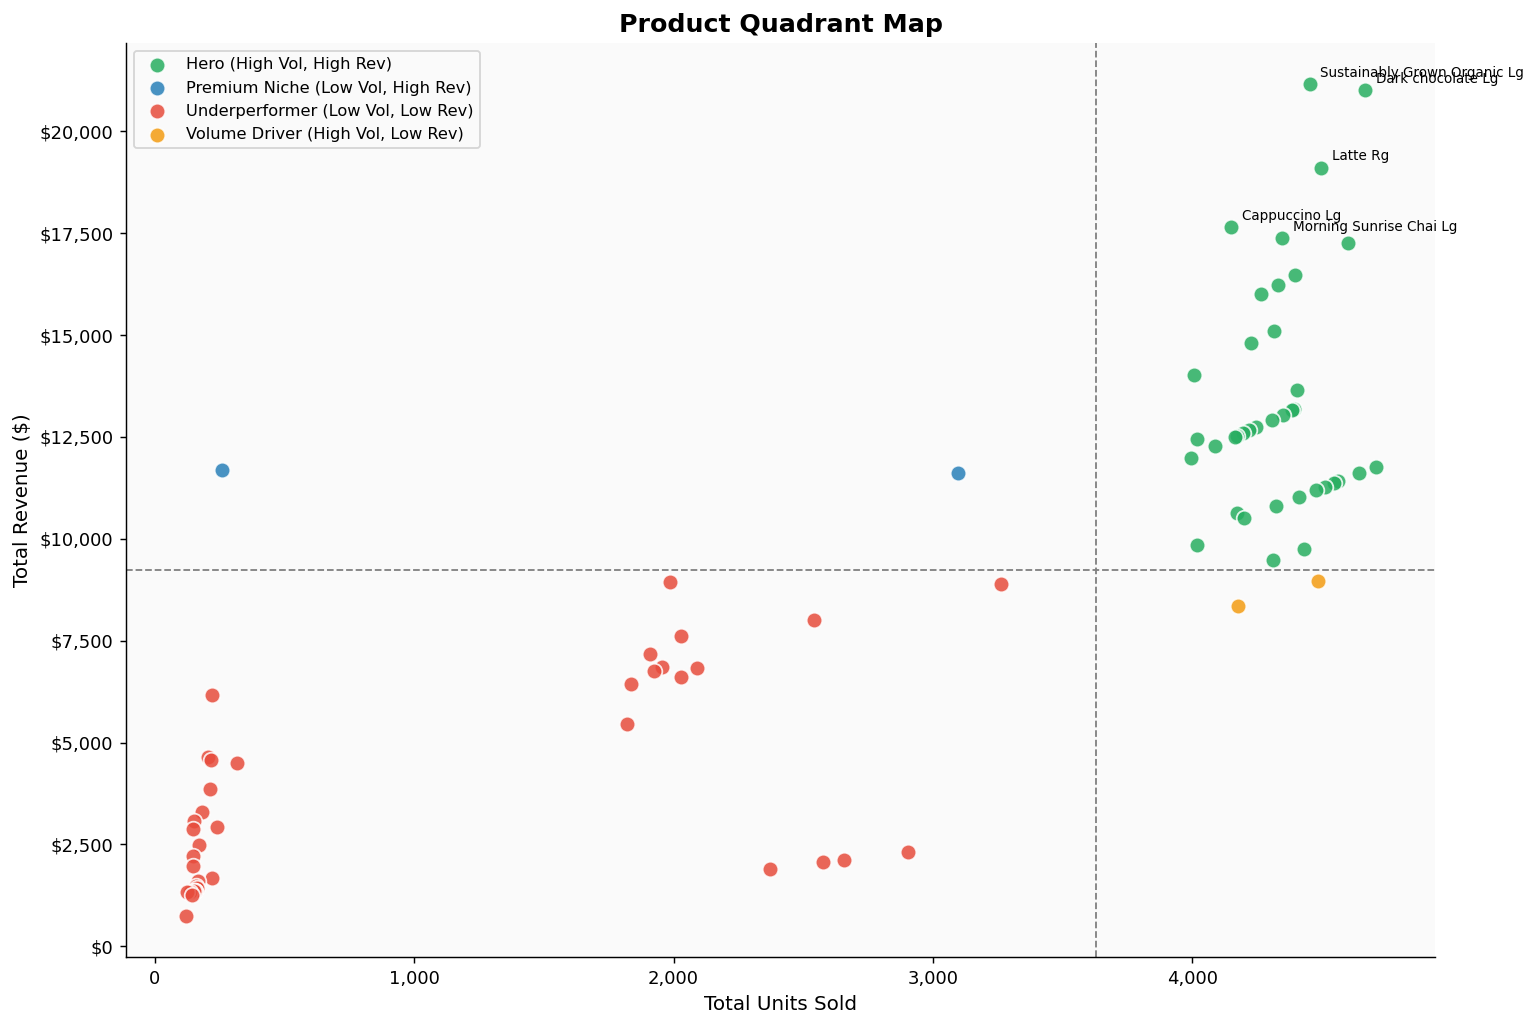

In [37]:
qcolors = {
    'Hero (High Vol, High Rev)'        : '#27ae60',
    'Premium Niche (Low Vol, High Rev)': '#2980b9',
    'Volume Driver (High Vol, Low Rev)': '#f39c12',
    'Underperformer (Low Vol, Low Rev)': '#e74c3c'
}

fig, ax = plt.subplots(figsize=(12, 8))
for quad, grp in rev_product.groupby('quadrant'):
    ax.scatter(grp['units_sold'], grp['total_revenue'],
               label=quad, color=qcolors[quad], s=75, alpha=0.85, edgecolors='white')

ax.axvline(med_units,   color='gray', linestyle='--', linewidth=1)
ax.axhline(med_revenue, color='gray', linestyle='--', linewidth=1)

for _, row in rev_product[rev_product['quadrant']=='Hero (High Vol, High Rev)'].head(5).iterrows():
    ax.annotate(row['product_detail'],
                xy=(row['units_sold'], row['total_revenue']),
                xytext=(6, 4), textcoords='offset points', fontsize=7.5)

ax.set_xlabel('Total Units Sold')
ax.set_ylabel('Total Revenue ($)')
ax.set_title('Product Quadrant Map', fontweight='bold')
ax.xaxis.set_major_formatter(FMT_NUM)
ax.yaxis.set_major_formatter(FMT_USD)
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

In [38]:
print('HERO PRODUCTS:')
rev_product[rev_product['quadrant']=='Hero (High Vol, High Rev)'][
    ['product_detail','units_sold','total_revenue','revenue_share_pct']
].sort_values('total_revenue', ascending=False).reset_index(drop=True)

HERO PRODUCTS:


,product_detail,units_sold,total_revenue,revenue_share_pct
0,Sustainably Grown Organic Lg,4453,21151.75,3.03
1,Dark chocolate Lg,4668,21006.00,3.01
2,Latte Rg,4497,19112.25,2.73
3,Cappuccino Lg,4151,17641.75,2.52
4,Morning Sunrise Chai Lg,4346,17384.00,2.49
5,Latte,4602,17257.50,2.47
6,Jamaican Coffee River Lg,4395,16481.25,2.36
7,Sustainably Grown Organic Rg,4329,16233.75,2.32
8,Cappuccino,4266,15997.50,2.29
9,Brazilian Lg,4317,15109.50,2.16


In [39]:
print('UNDERPERFORMERS:')
rev_product[rev_product['quadrant']=='Underperformer (Low Vol, Low Rev)'][
    ['product_detail','units_sold','total_revenue','revenue_share_pct']
].sort_values('total_revenue').reset_index(drop=True)


UNDERPERFORMERS:


,product_detail,units_sold,total_revenue,revenue_share_pct
0,Dark chocolate,118,755.20,0.11
1,Earl Grey,142,1270.90,0.18
2,Spicy Eye Opener Chai,122,1335.90,0.19
3,Guatemalan Sustainably Grown,134,1340.00,0.19
4,Lemon Grass,152,1360.40,0.19
5,Peppermint,153,1369.35,0.20
6,Traditional Blend Chai,153,1369.35,0.20
7,English Breakfast,161,1440.95,0.21
8,Serenity Green Tea,159,1470.75,0.21
9,Morning Sunrise Chai,168,1596.00,0.23


In [40]:
store_rev = (
    df_clean.groupby('store_location')
    .agg(units_sold=('transaction_qty','sum'),
         total_revenue=('revenue','sum'),
         transactions=('transaction_id','nunique'))
    .reset_index()
    .sort_values('total_revenue', ascending=False)
)
store_rev['revenue_share_pct']     = (store_rev['total_revenue'] / TOTAL_REVENUE * 100).round(2)
store_rev['avg_transaction_value'] = (store_rev['total_revenue'] / store_rev['transactions']).round(2)
store_rev

,store_location,units_sold,total_revenue,transactions,revenue_share_pct,avg_transaction_value
1,Hell's Kitchen,71737,236511.17,50735,33.84,4.66
0,Astoria,70991,232243.91,50599,33.23,4.59
2,Lower Manhattan,71742,230057.25,47782,32.92,4.81


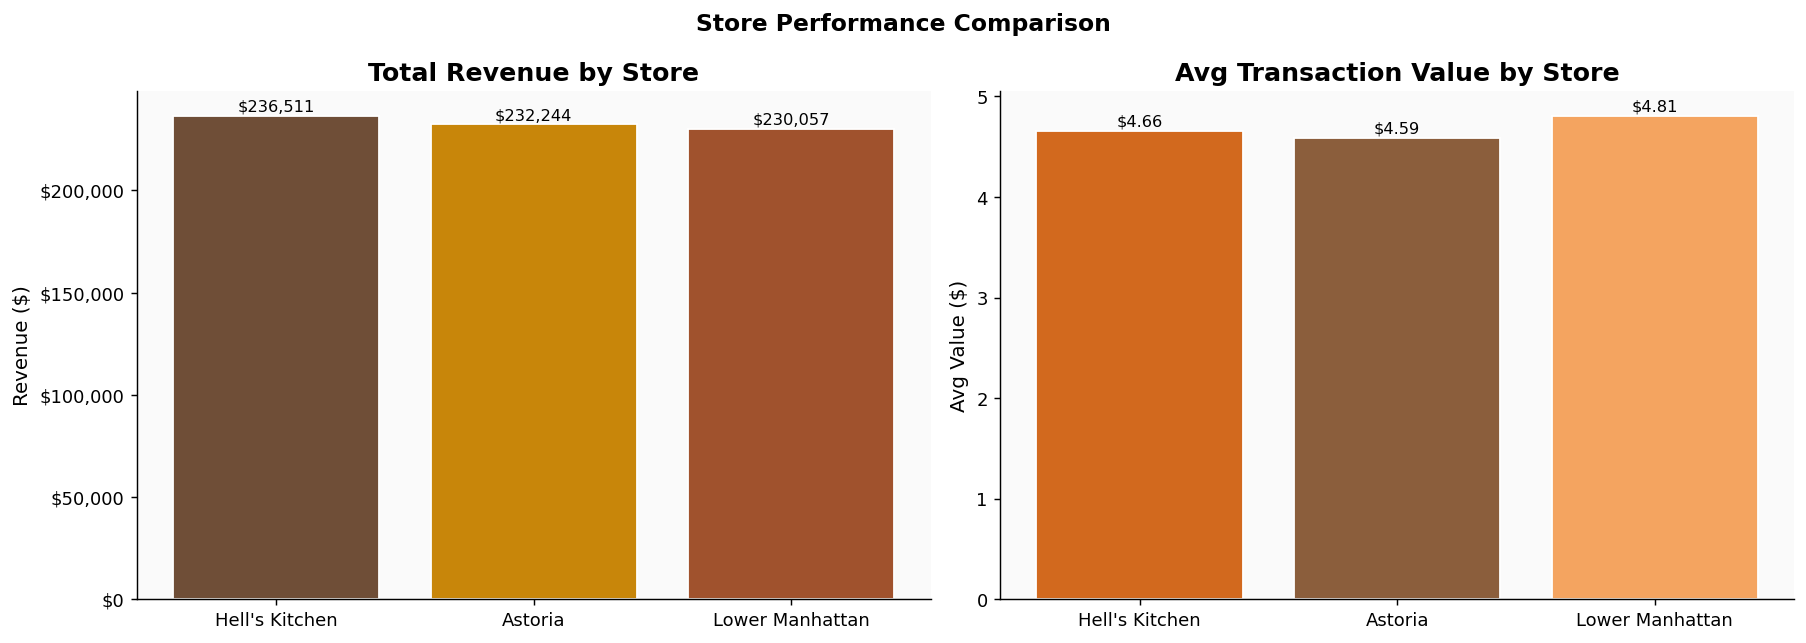

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(store_rev['store_location'], store_rev['total_revenue'],
                   color=BRAND[:3], edgecolor='white')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                 f'${bar.get_height():,.0f}', ha='center', fontsize=9)
axes[0].set_title('Total Revenue by Store', fontweight='bold')
axes[0].set_ylabel('Revenue ($)')
axes[0].yaxis.set_major_formatter(FMT_USD)

bars2 = axes[1].bar(store_rev['store_location'], store_rev['avg_transaction_value'],
                    color=BRAND[3:6], edgecolor='white')
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                 f'${bar.get_height():.2f}', ha='center', fontsize=9)
axes[1].set_title('Avg Transaction Value by Store', fontweight='bold')
axes[1].set_ylabel('Avg Value ($)')

plt.suptitle('Store Performance Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

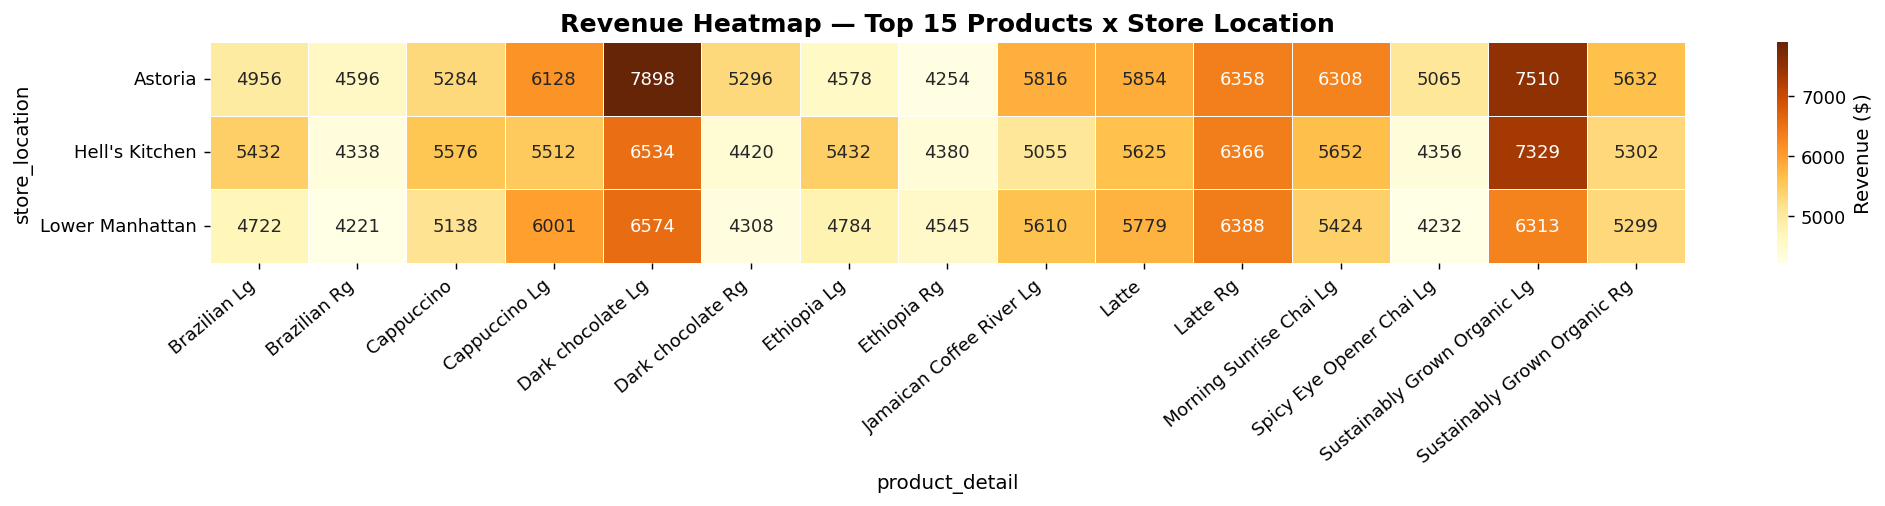

In [42]:
top15 = rev_product.head(15)['product_detail'].tolist()

heatmap_data = (
    df_clean[df_clean['product_detail'].isin(top15)]
    .groupby(['store_location','product_detail'])['revenue']
    .sum().unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrBr',
            linewidths=0.4, ax=ax, cbar_kws={'label':'Revenue ($)'})
ax.set_title('Revenue Heatmap — Top 15 Products x Store Location', fontweight='bold')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

In [43]:
top_product     = rev_product.iloc[0]
top_category    = cat_rev.iloc[0]
top5_conc       = rev_product.head(5)['revenue_share_pct'].sum()
hero_count      = (rev_product['quadrant'] == 'Hero (High Vol, High Rev)').sum()
underp_count    = (rev_product['quadrant'] == 'Underperformer (Low Vol, Low Rev)').sum()
avg_rev_per_sku = TOTAL_REVENUE / len(rev_product)

print('=' * 65)
print('  KEY PERFORMANCE INDICATORS')
print('=' * 65)
print(f'  Total Revenue                : ${TOTAL_REVENUE:>13,.2f}')
print(f'  Total SKUs                   : {len(rev_product):>14}')
print(f'  Avg Revenue per SKU          : ${avg_rev_per_sku:>13,.2f}')
print(f'  Top Product                  : {top_product["product_detail"]}')
print(f'  Top Product Revenue Share    : {top_product["revenue_share_pct"]:>13.2f}%')
print(f'  Top Category                 : {top_category["product_category"]}')
print(f'  Top Category Revenue Share   : {top_category["revenue_share_pct"]:>13.2f}%')
print(f'  Top-5 Concentration          : {top5_conc:>13.2f}%')
print(f'  Products driving 80% revenue : {products_80:>14}  ({pct_products_80}% of menu)')
print(f'  Hero Products                : {hero_count:>14}')
print(f'  Underperforming Products     : {underp_count:>14}')
print('=' * 65)

  KEY PERFORMANCE INDICATORS
  Total Revenue                : $   698,812.33
  Total SKUs                   :             80
  Avg Revenue per SKU          : $     8,735.15
  Top Product                  : Sustainably Grown Organic Lg
  Top Product Revenue Share    :          3.03%
  Top Category                 : Coffee
  Top Category Revenue Share   :         38.63%
  Top-5 Concentration          :         13.78%
  Products driving 80% revenue :             43  (53.8% of menu)
  Hero Products                :             38
  Underperforming Products     :             38


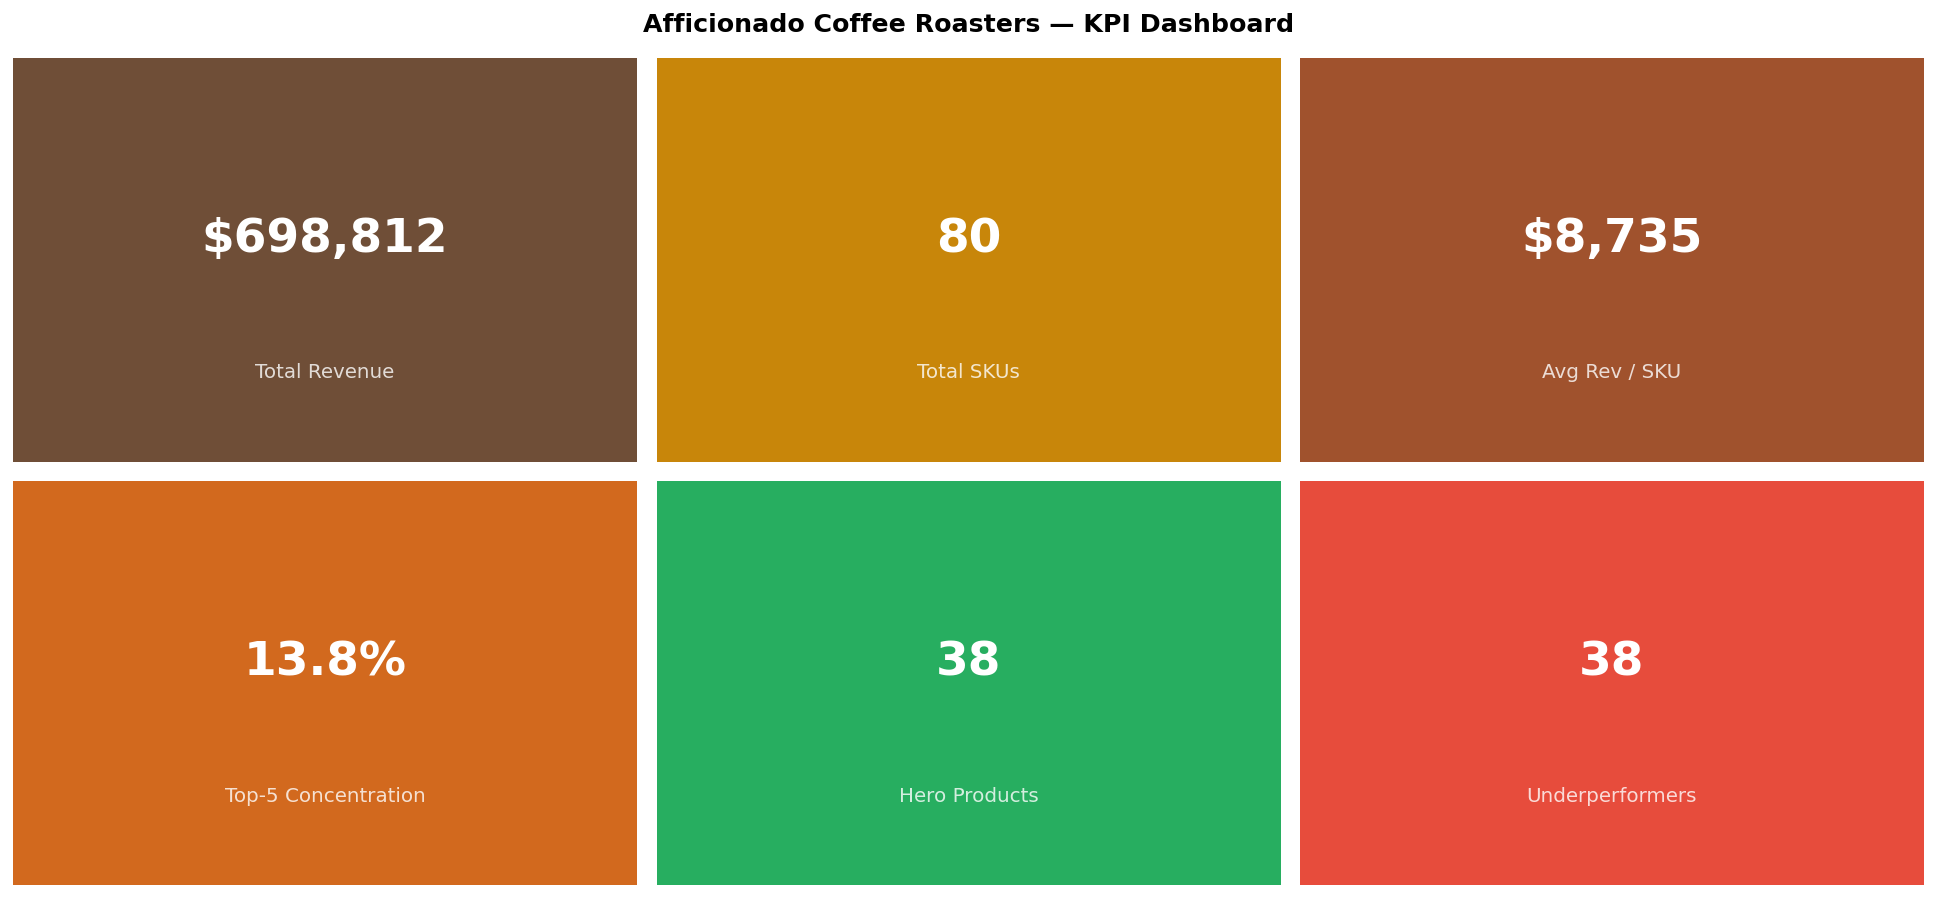

In [44]:
kpis = [
    ('Total Revenue',       f'${TOTAL_REVENUE:,.0f}',  '#6F4E37'),
    ('Total SKUs',          f'{len(rev_product)}',      '#C8860A'),
    ('Avg Rev / SKU',       f'${avg_rev_per_sku:,.0f}', '#A0522D'),
    ('Top-5 Concentration', f'{top5_conc:.1f}%',        '#D2691E'),
    ('Hero Products',       f'{hero_count}',            '#27ae60'),
    ('Underperformers',     f'{underp_count}',          '#e74c3c'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, (title, val, color) in zip(axes.flatten(), kpis):
    ax.set_facecolor(color)
    ax.text(0.5, 0.55, val, ha='center', va='center',
            fontsize=26, fontweight='bold', color='white', transform=ax.transAxes)
    ax.text(0.5, 0.22, title, ha='center', va='center',
            fontsize=11, color='#ffffffcc', transform=ax.transAxes)
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values(): s.set_visible(False)

plt.suptitle('Afficionado Coffee Roasters — KPI Dashboard', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()